# Epinet

In [1]:
%%capture
%pip install git+https://github.com/lightning-uq-box/lightning-uq-box.git

## Theoretic Foundation

An *epistemic neural network* (ENN), introduced by [Osband et al., 2023](https://arxiv.org/abs/2107.08924), is a pair: a function class $f_\theta(x, z)$ and a reference distribution $P_Z$ over an **epistemic index** $z$. Where a conventional network maps an input to a single prediction, an ENN maps an input *and an index* to a prediction, and integrating over $z \sim P_Z$ recovers a predictive distribution.

This representation provides *joint* predictions. Most UQ methods are evaluated one input at a time, using marginal predictions $\hat{P}(y_t \mid x_t)$. However, sequential decision making, active learning, and bandits can depend on covariance between predictions at different inputs. An ENN's joint prediction over $\tau$ inputs is

$$\hat{P}_{1:\tau}(y_{1:\tau}) = \int P_Z(dz) \prod_{t=1}^{\tau} \mathrm{softmax}(f_\theta(x_t, z))_{y_t},$$

where the shared $z$ inside the product is what ties the predictions together.

The **epinet** implements an ENN by adding a small head to a conventional base network $\mu_\zeta(x)$:

$$f_\theta(x, z) = \mu_\zeta(x) + \sigma_\eta(\mathrm{sg}[\phi_\zeta(x)], z),$$

where $\phi_\zeta(x)$ are features of the base network's last hidden layer and $\mathrm{sg}[\cdot]$ is a stop-gradient: the epinet reads the base network's features but never sends gradients back through them. The epinet itself splits into a learnable part and a *fixed* part,

$$\sigma_\eta(\tilde{x}, z) = \sigma^L_\eta(\tilde{x}, z) + \sigma^P(\tilde{x}, z), \qquad \sigma^L_\eta(\tilde{x}, z) := \mathrm{mlp}_\eta([\tilde{x}, z])^T z.$$

The learnable part is an MLP whose output is reshaped to $\mathbb{R}^{D_Z \times C}$ and contracted with the index. The fixed part $\sigma^P$ is a frozen, randomly initialized *prior function*. It is never trained, and it is what supplies uncertainty where the data does not pin the model down: away from the training data nothing pulls the learnable part toward cancelling it, so the prior's variation across $z$ survives as predictive spread.

The base network is read but not modified, so an epinet can be attached to a **large pretrained network whose weights remain frozen**. Because only the small head receives the index, averaging the loss over many index draws requires one base-network forward pass. The paper reports lower ImageNet joint log-loss than a 100-particle deep ensemble at less than the cost of two particles.

## Imports

In [2]:
import os
import tempfile
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import torch
from lightning import Trainer
from lightning.pytorch import seed_everything
from lightning.pytorch.loggers import CSVLogger
from torch import nn
from torch.optim import Adam

from lightning_uq_box.datamodules import TwoMoonsDataModule
from lightning_uq_box.eval_utils import joint_log_loss_dyadic, marginal_log_loss
from lightning_uq_box.models import MLP
from lightning_uq_box.uq_methods import EpinetClassification
from lightning_uq_box.viz_utils import (
    plot_predictions_classification,
    plot_training_metrics,
    plot_two_moons_data,
)

torch.set_num_threads(1)
plt.rcParams["figure.figsize"] = [14, 5]

In [3]:
seed_everything(0)

Seed set to 0


0

We define a temporary directory to look at some training metrics and results.

In [4]:
my_temp_dir = tempfile.mkdtemp()

## Datamodule

We use the Two Moons dataset, a two-dimensional binary classification problem. Its appeal here is that the input space is small enough to visualize completely, so we can see exactly where the model is and is not confident.

In [5]:
dm = TwoMoonsDataModule(batch_size=128)

X_train, Y_train, X_test, Y_test, test_grid_points = (
    dm.X_train,
    dm.Y_train,
    dm.X_test,
    dm.Y_test,
    dm.test_grid_points,
)

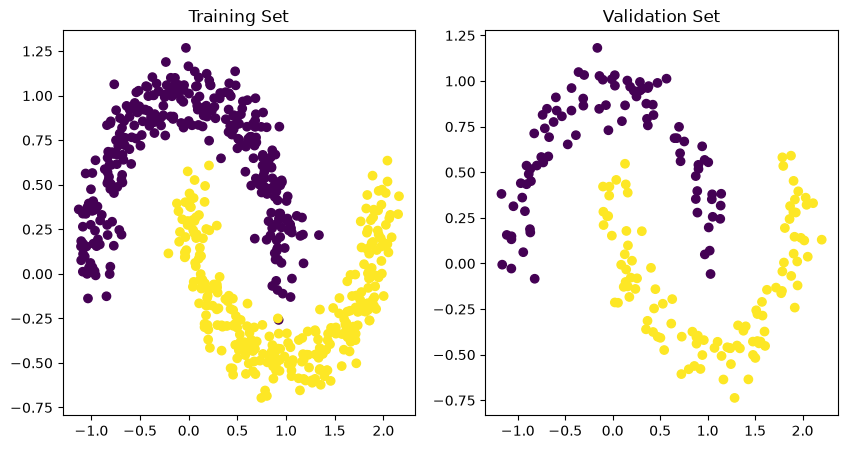

In [6]:
fig = plot_two_moons_data(X_train, Y_train, X_test, Y_test)

## Model

As in the regression case we begin with an ordinary base network, which the epinet will read from without modifying.

In [7]:
network = MLP(n_inputs=2, n_hidden=[50, 50], n_outputs=2, activation_fn=nn.ReLU())
network

MLP(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=50, out_features=2, bias=True)
  )
)

`EpinetClassification` wraps it. The loss is the ordinary cross-entropy: the epinet needs no special loss function, because averaging the standard loss over sampled indices is exactly what the paper prescribes.

In [8]:
epinet_module = EpinetClassification(
    model=network,
    optimizer=partial(Adam, lr=1e-2),
    loss_fn=nn.CrossEntropyLoss(),
    task="multiclass",
    index_dim=8,
    num_index_samples=8,
    num_pred_samples=100,
    epinet_hidden_dims=[15, 15],
    prior_hidden_dims=[5, 5],
    epi_prior_scale=0.0,
    input_prior_scale=3.0,
)

## Trainer

In [9]:
logger = CSVLogger(my_temp_dir)
trainer = Trainer(
    accelerator="cpu",
    max_epochs=100,  # number of epochs we want to train
    logger=logger,  # log training metrics for later evaluation
    log_every_n_steps=1,
    enable_checkpointing=False,
    enable_progress_bar=False,
    default_root_dir=my_temp_dir,
)

In [10]:
trainer.fit(epinet_module, dm)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ MLP              │  2.8 K │ train │     0 │
│ 1 │ loss_fn       │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 5 │ epinet        │ Epinet           │  3.3 K │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 4.2 K                                                                                            
Non-trainable params: 1.9 K                                                                                        
Total params: 6.1 K                                                                                                
Total estimated model params size (MB): 0.024                                                                      
Modules in train mode: 29                                                                                          
Modules in eval mode: 57                                                                                           
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=100` reached.


## Training Metrics

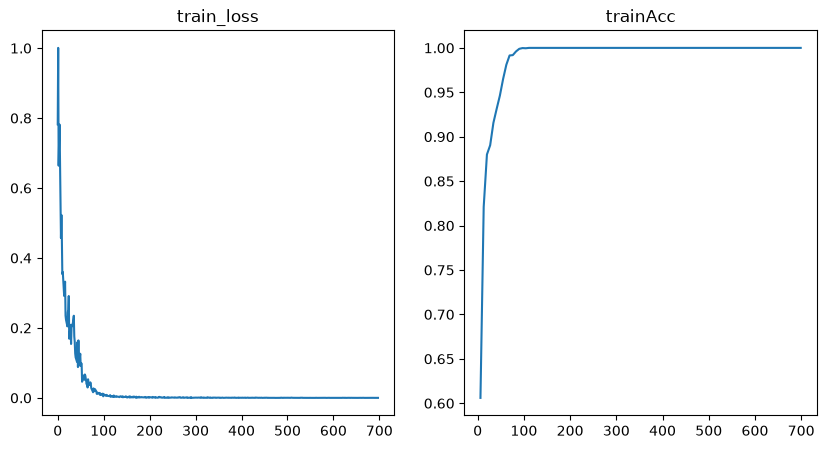

In [11]:
fig = plot_training_metrics(
    os.path.join(my_temp_dir, "lightning_logs"), ["train_loss", "trainAcc"]
)

## Prediction

In [12]:
# save predictions
trainer.test(epinet_module, dm.test_dataloader())

[{'testAcc': 1.0,
  'testCalibration': 0.0006211852887645364,
  'testEmpirical Coverage': 1.0}]

In [13]:
preds = epinet_module.predict_step(test_grid_points.to(epinet_module.device))

## Evaluate Predictions

Evaluating over the full input grid shows where the epinet is uncertain. The uncertainty should be low along the two moons, where the training data pins the model down, and rise in the gap between them and away from the data entirely.

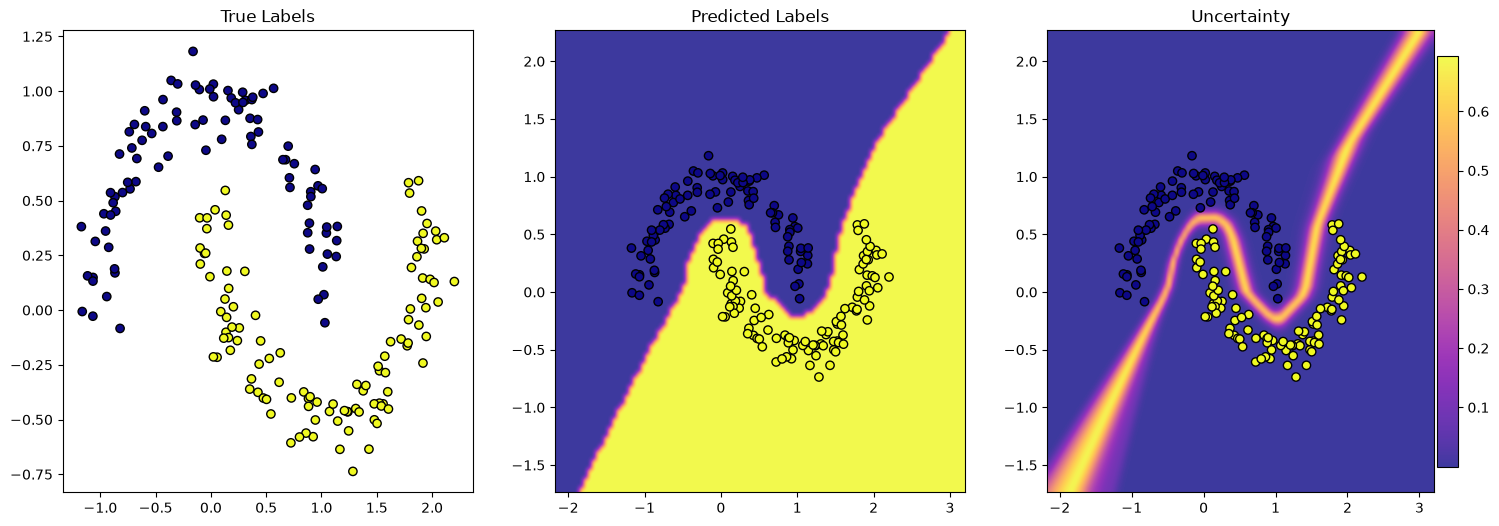

In [14]:
fig = plot_predictions_classification(
    X_test, Y_test, preds["pred"].argmax(-1), test_grid_points, preds["pred_uct"]
)

## Joint Predictions

Everything so far has been a *marginal* evaluation, in which each point is scored independently. ENNs also define *joint* predictions, which can be evaluated with the metrics provided by the box.

The distinction is easiest to see by drawing the individual index samples, exactly as the regression tutorial draws its sample functions. Each $z$ gives a different classifier; where the data pins the model down the boundaries agree, and where it does not they fan out.


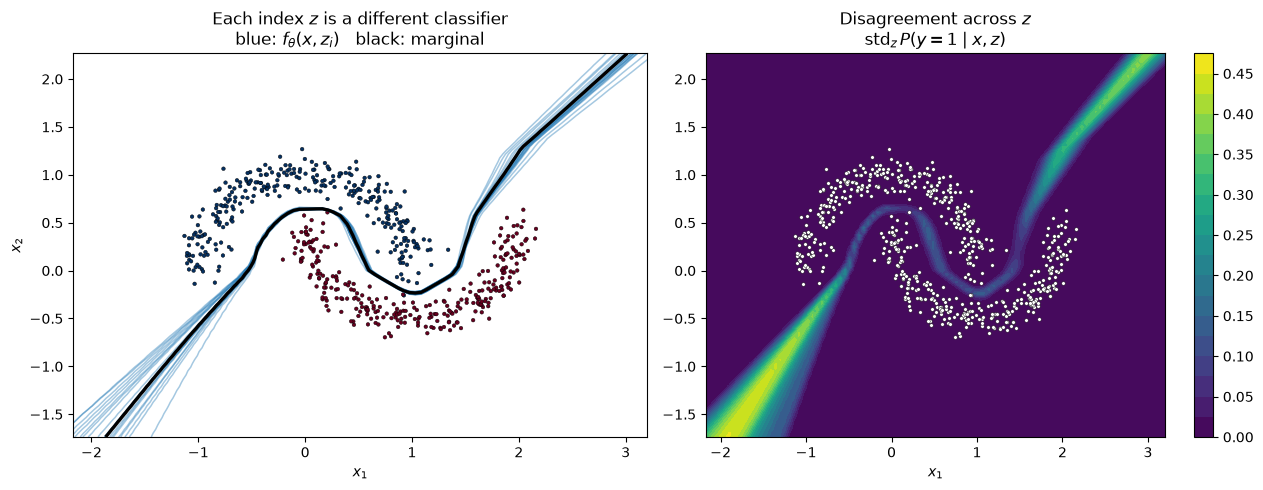

In [15]:
samples = preds["logits"].permute(2, 0, 1).softmax(-1)[..., 1].cpu().numpy()
side = int(np.sqrt(test_grid_points.shape[0]))
xs = test_grid_points[:, 0].reshape(side, side).cpu().numpy()
ys = test_grid_points[:, 1].reshape(side, side).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i in range(20):
    ax.contour(
        xs,
        ys,
        samples[i].reshape(side, side),
        levels=[0.5],
        colors="C0",
        alpha=0.4,
        linewidths=1.1,
    )
ax.contour(
    xs,
    ys,
    samples.mean(0).reshape(side, side),
    levels=[0.5],
    colors="k",
    linewidths=2.4,
)
ax.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=Y_train,
    cmap="RdBu_r",
    s=7,
    edgecolor="k",
    linewidth=0.3,
)
ax.set_xlim(xs.min(), xs.max())
ax.set_ylim(ys.min(), ys.max())
ax.set_title(
    "Each index $z$ is a different classifier\nblue: $f_\\theta(x, z_i)$   black: marginal"
)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

ax = axes[1]
m = ax.contourf(xs, ys, samples.std(0).reshape(side, side), levels=20, cmap="viridis")
ax.scatter(X_train[:, 0], X_train[:, 1], c="w", s=7, edgecolor="k", linewidth=0.3)
plt.colorbar(m, ax=ax)
ax.set_title("Disagreement across $z$\n$\\mathrm{std}_z\\,P(y{=}1 \\mid x, z)$")
ax.set_xlabel("$x_1$")
plt.tight_layout()
plt.show()

The left panel shows that the epinet produces *a set of coherent alternative classifiers*, rather than only wider uncertainty near the boundary. A marginal metric cannot distinguish this behavior, because averaging the samples gives the same per-point probabilities either way.

`marginal_log_loss` collapses the index samples into one predictive distribution per input and scores each independently. `joint_log_loss_dyadic` keeps the samples tied across a batch of $\tau$ inputs and scores the batch as a whole. The batches themselves are drawn by *dyadic sampling*, which is worth a closer look.

### Dyadic sampling

A joint metric scores a batch of $\tau$ inputs. If the inputs are drawn i.i.d. from the test set, they usually probe unrelated marginals, and the joint score is close to the sum of marginal scores. To assess prediction coherence, a batch must include repeated inputs.

**Dyadic sampling** ([Appendix F](https://arxiv.org/abs/2107.08924)) first draws $\kappa$ *anchor* points uniformly from the evaluation set, then fills the $\tau$ batch slots by resampling those anchors with replacement. Here, $\kappa$ controls the amount of repetition and $\tau$ the number of predictions scored jointly. This notebook uses the paper's default of $\kappa = 2$ and $\tau = 10$, so a batch of ten slots contains two distinct inputs, each appearing about five times.

Repeated anchors expose whether index samples are internally consistent. A model with consistent samples gives the same answer for each repeat of an anchor. A model that treats predictions as independent can give different answers at each slot. Marginal scoring does not test this behavior because it scores each input separately.

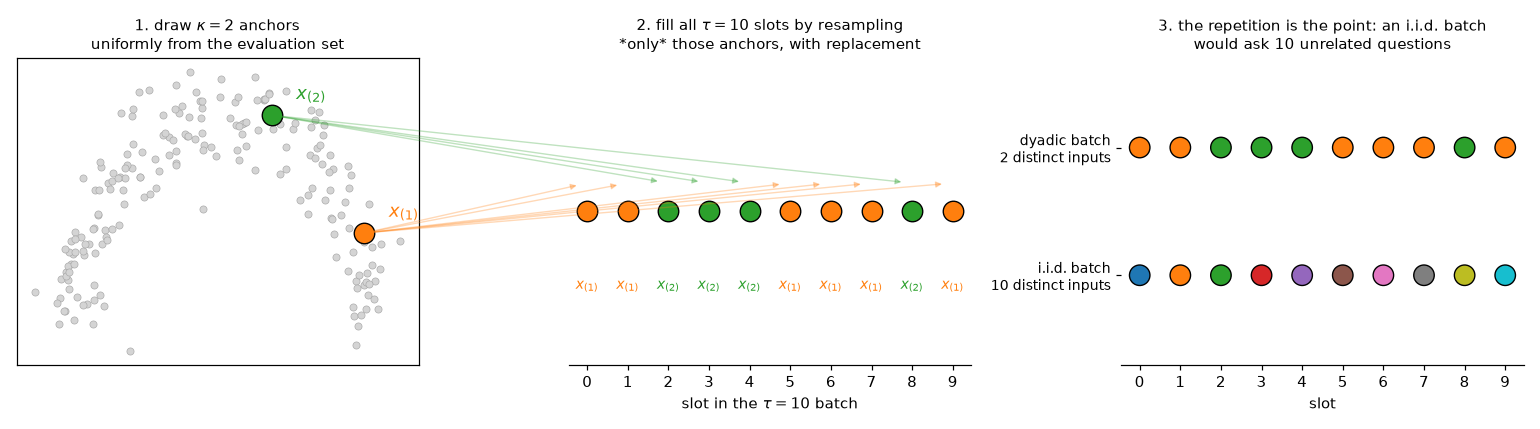

In [ ]:
from matplotlib.patches import ConnectionPatch

from lightning_uq_box.eval_utils.joint_prediction import dyadic_batch_indices

num_data, tau, kappa = 200, 10, 2
batch = dyadic_batch_indices(
    num_data, tau=tau, kappa=kappa, generator=torch.Generator().manual_seed(3)
)
# which of the kappa anchors landed in each slot, recovered from the batch itself
anchor_ids, slot_of = torch.unique(batch, return_inverse=True)

rng = np.random.default_rng(0)
angle = rng.uniform(0, np.pi, num_data)
pool = np.stack(
    [
        np.cos(angle) + rng.normal(0, 0.12, num_data),
        np.sin(angle) + rng.normal(0, 0.12, num_data),
    ],
    axis=1,
)
anchor_colors = ["C1", "C2"]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))

ax = axes[0]
ax.scatter(pool[:, 0], pool[:, 1], s=22, c="0.83", edgecolor="0.65", linewidth=0.4)
for j, a in enumerate(anchor_ids.tolist()):
    ax.scatter(
        *pool[a], s=180, c=anchor_colors[j], edgecolor="k", linewidth=0.9, zorder=3
    )
    ax.annotate(
        f"$x_{{({j + 1})}}$",
        pool[a],
        textcoords="offset points",
        xytext=(16, 10),
        fontsize=12,
        fontweight="bold",
        color=anchor_colors[j],
    )
ax.set_title(
    "1. draw $\\kappa=2$ anchors\nuniformly from the evaluation set", fontsize=10
)
ax.set_xticks([])
ax.set_yticks([])


ax = axes[1]
for slot, j in enumerate(slot_of.tolist()):
    ax.scatter(
        slot, 0, s=180, c=anchor_colors[j], edgecolor="k", linewidth=0.9, zorder=3
    )
    ax.text(
        slot,
        -0.33,
        f"$x_{{({j + 1})}}$",
        ha="center",
        fontsize=9,
        color=anchor_colors[j],
    )
ax.set_xticks(range(tau))
ax.set_yticks([])
ax.set_xlabel("slot in the $\\tau=10$ batch")
ax.set_ylim(-0.65, 0.65)
ax.set_title(
    "2. fill all $\\tau=10$ slots by resampling\n*only* those anchors, with replacement",
    fontsize=10,
)
for side in ("left", "right", "top"):
    ax.spines[side].set_visible(False)

for j, a in enumerate(anchor_ids.tolist()):
    for slot in (slot_of == j).nonzero().flatten().tolist():
        fig.add_artist(
            ConnectionPatch(
                xyA=pool[a],
                coordsA=axes[0].transData,
                xyB=(slot, 0.12),
                coordsB=axes[1].transData,
                arrowstyle="-|>",
                mutation_scale=8,
                shrinkB=7,
                color=anchor_colors[j],
                alpha=0.30,
                linewidth=0.9,
            )
        )

ax = axes[2]
ax.scatter(
    range(tau),
    [1] * tau,
    s=180,
    c=[anchor_colors[j] for j in slot_of.tolist()],
    edgecolor="k",
    linewidth=0.9,
    zorder=3,
)
ax.scatter(
    range(tau),
    [0] * tau,
    s=180,
    c=[plt.cm.tab10(i) for i in range(tau)],
    edgecolor="k",
    linewidth=0.9,
    zorder=3,
)
ax.set_yticks([0, 1])
ax.set_yticklabels(
    ["i.i.d. batch\n10 distinct inputs", "dyadic batch\n2 distinct inputs"], fontsize=9
)
ax.set_xticks(range(tau))
ax.set_xlabel("slot")
ax.set_ylim(-0.7, 1.7)
ax.set_title(
    "3. an i.i.d. batch\nwould ask 10 unrelated questions",
    fontsize=10,
)
for side in ("left", "right", "top"):
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

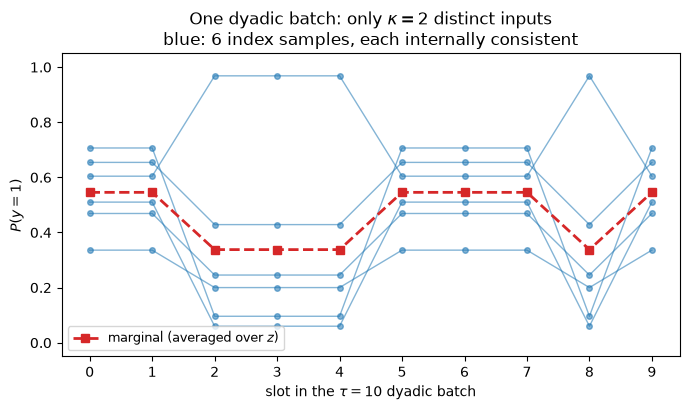

In [16]:
boundary = torch.topk(preds["pred_uct"], 200).indices
boundary_logits = preds["logits"][boundary].permute(2, 0, 1).cpu()
boundary_probs = boundary_logits.softmax(-1)

batch = dyadic_batch_indices(
    200, tau=10, kappa=2, generator=torch.Generator().manual_seed(3)
)

fig, ax = plt.subplots(figsize=(7, 4.2))
for row in range(6):
    ax.plot(
        range(10),
        boundary_probs[row, batch, 1],
        "o-",
        color="C0",
        alpha=0.55,
        ms=4,
        lw=1,
    )
ax.plot(
    range(10),
    boundary_probs.mean(0)[batch, 1],
    "s--",
    color="C3",
    lw=2,
    ms=6,
    label="marginal (averaged over $z$)",
)
ax.set_xticks(range(10))
ax.set_xlabel("slot in the $\\tau=10$ dyadic batch")
ax.set_ylabel("$P(y{=}1)$")
ax.set_ylim(-0.05, 1.05)
ax.set_title(
    "One dyadic batch: only $\\kappa=2$ distinct inputs\nblue: 6 index samples, each internally consistent"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Each blue line holds a *constant* value across repeats of the same anchor and steps only when the anchor changes. That self-consistency is what joint log-loss rewards.

We compare the epinet with a baseline that has **exactly the same marginals** but no dependence: every index sample is replaced by the averaged predictive distribution. Per-input metrics cannot distinguish the two by construction.

We label the evaluation points by drawing from a single held-out index sample, which stands in for a coherent "true" function; see the caveat below.

        epinet:  marginal 0.6959   joint (tau=10) 0.3541
 marginal-only:  marginal 0.6959   joint (tau=10) 0.6969


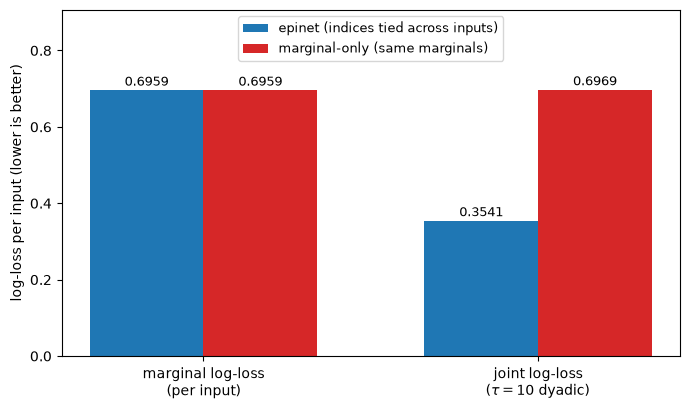

In [17]:
marginal_only = (
    torch.log(boundary_probs.mean(0) + 1e-12)
    .unsqueeze(0)
    .expand_as(boundary_logits)
    .contiguous()
)

generator = torch.Generator().manual_seed(0)
targets = torch.multinomial(boundary_probs[0], 1, generator=generator).squeeze(-1)

scores = {}
for name, logits in [("epinet", boundary_logits), ("marginal-only", marginal_only)]:
    scores[name] = (
        float(marginal_log_loss(logits, targets)),
        float(
            joint_log_loss_dyadic(
                logits,
                targets,
                tau=10,
                kappa=2,
                num_batches=500,
                generator=torch.Generator().manual_seed(0),
            )
        ),
    )
    print(
        f"{name:>14}:  marginal {scores[name][0]:.4f}   joint (tau=10) {scores[name][1]:.4f}"
    )

fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(2)
width = 0.34
epi = scores["epinet"]
mrg = scores["marginal-only"]
bars = list(
    ax.bar(
        x - width / 2,
        epi,
        width,
        label="epinet (indices tied across inputs)",
        color="C0",
    )
)
bars += list(
    ax.bar(
        x + width / 2, mrg, width, label="marginal-only (same marginals)", color="C3"
    )
)
for b in bars:
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.012,
        f"{b.get_height():.4f}",
        ha="center",
        fontsize=9,
    )
ax.set_xticks(x)
ax.set_xticklabels(
    ["marginal log-loss\n(per input)", "joint log-loss\n($\\tau=10$ dyadic)"]
)
ax.set_ylabel("log-loss per input (lower is better)")
ax.set_ylim(0, max(epi + mrg) * 1.3)
ax.legend(loc="upper center", fontsize=9)
plt.tight_layout()
plt.show()

The marginal scores agree to four decimals, while the joint scores differ by roughly a factor of two. Although per-input metrics cannot distinguish the two models, the joint metric can.

The targets are generated by the model itself, by drawing from one of its index samples. These results therefore demonstrate *dependence between predictions*, rather than calibration or accuracy on real labels. The marginal-only baseline is constructed rather than trained. The CIFAR-10 experiment in `experiments/epinet_cifar10/` compares the epinet, deep ensembles, and MC dropout on observed test labels.

`joint_log_loss_dyadic` reports log loss **per input** (joint loss divided by $\tau$). Compare methods at the same $\tau$, using the same observed targets and anchor draws.

## Joint Predictions on CIFAR-10

The Two Moons example uses self-generated labels. The CIFAR-10 evaluation in `experiments/epinet_cifar10/` instead uses observed labels. It trains a ResNet-18 base network on CIFAR-10, then fits an epinet head on the **frozen** base and compares it with deep ensembles of up to 30 members and MC dropout.

Running the full experiment takes about three GPU-hours. The cells below instead download cached test-set logits from the [Hugging Face Hub](https://huggingface.co/datasets/lightning-uq-box/epinet_cifar10_logits), a 26 MB table of model outputs, and perform the remaining calculations on CPU.

In [18]:
from pathlib import Path

from huggingface_hub import hf_hub_download

# The cached test-set logits published alongside this tutorial (26 MB). The
# default HF cache is shared across runs, so this downloads once per machine.
CIFAR_LOGITS = Path(
    hf_hub_download(
        repo_id="lightning-uq-box/epinet_cifar10_logits",
        filename="test_logits.pt",
        repo_type="dataset",
    )
)

cached = torch.load(CIFAR_LOGITS, weights_only=True)
cifar_labels = cached["labels"]
ensemble = cached["ensemble"].float()
cifar_agents = {
    "single net": ensemble[:1],
    "MC dropout": cached["dropout"].float(),
    "epinet": cached["epinet"].float(),
    "ensemble (3 members)": ensemble[:3],
    "ensemble (10 members)": ensemble[:10],
    "ensemble (30 members)": ensemble,
}
for name, logits in cifar_agents.items():
    error = float(
        (logits.softmax(-1).mean(0).argmax(-1) != cifar_labels).float().mean()
    )
    print(f"{name:>22}: {logits.shape[0]:>2} samples   test error {error:.4f}")

            single net:  1 samples   test error 0.0577
            MC dropout: 50 samples   test error 0.0566
                epinet: 50 samples   test error 0.0582
  ensemble (3 members):  3 samples   test error 0.0479
 ensemble (10 members): 10 samples   test error 0.0443


 ensemble (30 members): 30 samples   test error 0.0424


Because dyadic batches repeat their anchors, the number of inputs scored together, $\tau$, controls how much joint structure the metric can see. At $\tau = 1$ it reduces to the ordinary marginal log-loss and every method looks similar. Sweeping $\tau$ upward separates them.

In [19]:
taus = [1, 2, 3, 5, 10, 20, 30]
seeds = range(8)
curves = {}
for name, logits in cifar_agents.items():
    curves[name] = [
        np.mean(
            [
                float(
                    joint_log_loss_dyadic(
                        logits,
                        cifar_labels,
                        tau=tau,
                        kappa=2,
                        num_batches=400,
                        generator=torch.Generator().manual_seed(seed),
                    )
                )
                for seed in seeds
            ]
        )
        for tau in taus
    ]
print("computed joint log-loss over tau for", len(curves), "methods")

computed joint log-loss over tau for 6 methods


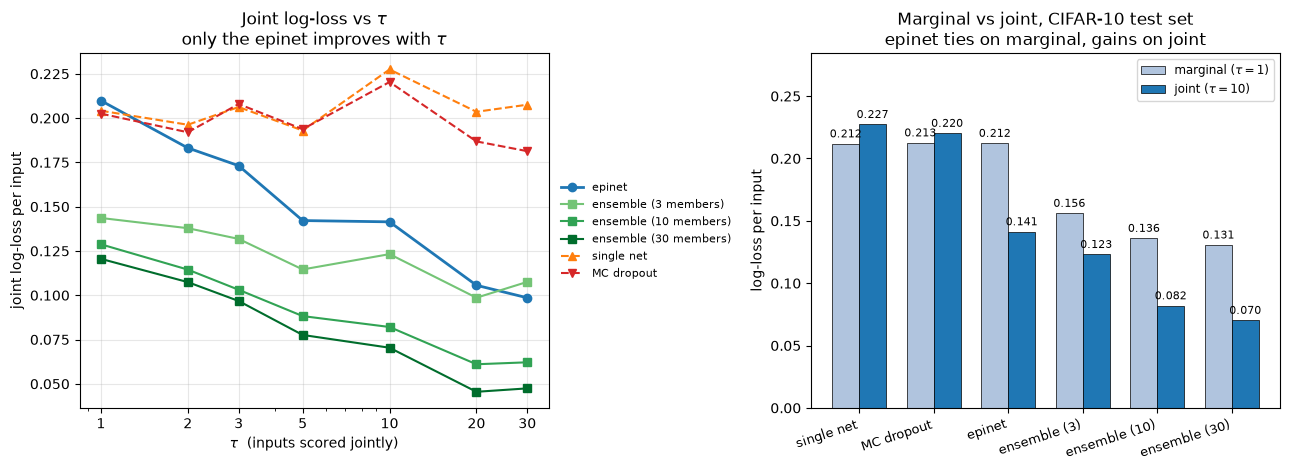

In [20]:
style = {
    "epinet": ("C0", "o", "-"),
    "ensemble (3 members)": ("#74c476", "s", "-"),
    "ensemble (10 members)": ("#31a354", "s", "-"),
    "ensemble (30 members)": ("#006d2c", "s", "-"),
    "single net": ("C1", "^", "--"),
    "MC dropout": ("C3", "v", "--"),
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
for name, (color, marker, ls) in style.items():
    ax.plot(
        taus,
        curves[name],
        color=color,
        marker=marker,
        ls=ls,
        lw=2.0 if name == "epinet" else 1.5,
        ms=6,
        label=name,
    )
ax.set_xscale("log")
ax.set_xticks(taus)
ax.set_xticklabels(taus)
ax.set_xlabel("$\\tau$  (inputs scored jointly)")
ax.set_ylabel("joint log-loss per input")
ax.set_title("Joint log-loss vs $\\tau$\nonly the epinet improves with $\\tau$")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.005, 0.5), frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
order = [
    "single net",
    "MC dropout",
    "epinet",
    "ensemble (3 members)",
    "ensemble (10 members)",
    "ensemble (30 members)",
]
marg = [float(marginal_log_loss(cifar_agents[n], cifar_labels)) for n in order]
joint = [curves[n][taus.index(10)] for n in order]
x = np.arange(len(order))
width = 0.36
ax.bar(
    x - width / 2,
    marg,
    width,
    label="marginal ($\\tau=1$)",
    color="lightsteelblue",
    edgecolor="k",
    lw=0.5,
)
ax.bar(
    x + width / 2,
    joint,
    width,
    label="joint ($\\tau=10$)",
    color="C0",
    edgecolor="k",
    lw=0.5,
)
for i, (a, b) in enumerate(zip(marg, joint)):
    ax.text(i - width / 2, a + 0.005, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(i + width / 2, b + 0.005, f"{b:.3f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(
    [n.replace(" members", "") for n in order], rotation=18, ha="right", fontsize=9
)
ax.set_ylabel("log-loss per input")
ax.set_ylim(0, max(marg + joint) * 1.25)
ax.legend(fontsize=8.5)
ax.set_title(
    "Marginal vs joint, CIFAR-10 test set\nepinet ties on marginal, gains on joint"
)
plt.tight_layout()
plt.show()

At $\tau = 1$, the epinet starts level with the single network and MC dropout. Its joint log-loss falls steadily as $\tau$ grows, whereas the two baselines remain roughly flat: their predictions contain little joint structure for the metric to capture. By $\tau = 30$, the epinet's joint log-loss has more than halved, from 0.210 to 0.099, and is lower than that of the 3-member ensemble.

The right panel makes the split explicit at $\tau = 10$. On the marginal metric the epinet is indistinguishable from the single network — it is scoring the same frozen base network, after all — and every ensemble beats all three. On the joint metric it separates from both baselines and closes most of the gap to the 3-member ensemble.

The epinet does not outperform every ensemble size on CIFAR-10. The ensemble continues to improve through 30 members, reaching a joint log-loss of 0.047 at $\tau = 30$, compared with 0.099 for the epinet. The epinet's quality lies between the 3- and 10-member ensembles. In the testbed experiment in the same directory, the ensemble curve is nearly flat (10 members improve joint log-loss by 0.0006), and the epinet performs better.

This comparison considers quality only; the methods also differ substantially in cost.

## The Cost Side: Parameters and FLOPs

Joint log-loss alone does not show the computational cost of each method. An ensemble of $k$ members consists of $k$ independent ResNets, with $k$ times the parameters and $k$ full forward passes per prediction. The epinet adds a small head to a backbone that runs **once**, then evaluates only that head for each index sample.

`run.py evaluate` records inference FLOPs per image with `torch.utils.flop_counter.FlopCounterMode`. It counts a full posterior draw for each method: 50 index samples for the epinet, 50 dropout draws for MC dropout, and $k$ passes for a $k$-member ensemble. The numbers below use these recorded FLOPs.

In [21]:
# Measured by run.py and written next to the cached logits as flop_counts.json
# and parameter_counts.json. Inlined here so this section runs standalone.
flop_counts = {
    "single net": 1_110_845_440,
    "MC dropout": 1_111_347_200,
    "epinet": 1_118_205_440,
    "ensemble (3 members)": 3_332_536_320,
    "ensemble (10 members)": 11_108_454_400,
    "ensemble (30 members)": 33_325_363_200,
}
param_counts = {
    "single net": 11_173_962,
    "MC dropout": 11_173_962,
    "epinet": 11_298_982,
    "ensemble (3 members)": 33_521_886,
    "ensemble (10 members)": 111_739_620,
    "ensemble (30 members)": 335_218_860,
}
BASE_FLOPS = flop_counts["single net"]
BASE_PARAMS = param_counts["single net"]
TRAINABLE_EPINET = 36_850  # the rest of the epinet head is the frozen prior

print(
    f"{'agent':>22}  {'GFLOP/img':>10}  {'vs single':>10}  {'params':>12}  {'vs single':>10}"
)
for name, flops in flop_counts.items():
    params = param_counts[name]
    print(
        f"{name:>22}  {flops / 1e9:>10.3f}  "
        f"{flops / BASE_FLOPS:>9.2f}x  {params:>12,}  "
        f"{params / BASE_PARAMS:>9.2f}x"
    )
print(
    f"\nepinet trainable parameters: {TRAINABLE_EPINET:,} "
    f"({100 * TRAINABLE_EPINET / BASE_PARAMS:.2f}% of the frozen base)"
)

                 agent   GFLOP/img   vs single        params   vs single
            single net       1.111       1.00x    11,173,962       1.00x
            MC dropout       1.111       1.00x    11,173,962       1.00x
                epinet       1.118       1.01x    11,298,982       1.01x
  ensemble (3 members)       3.333       3.00x    33,521,886       3.00x
 ensemble (10 members)      11.108      10.00x   111,739,620      10.00x
 ensemble (30 members)      33.325      30.00x   335,218,860      30.00x

epinet trainable parameters: 36,850 (0.33% of the frozen base)


The epinet's 50 index samples cost **0.7% more compute than a single forward pass**, because they share one backbone evaluation and differ only in a head with 37k trainable parameters. A 30-member ensemble costs 30× as much compute and memory, and its members must be trained separately.

The next plot compares quality with inference cost.

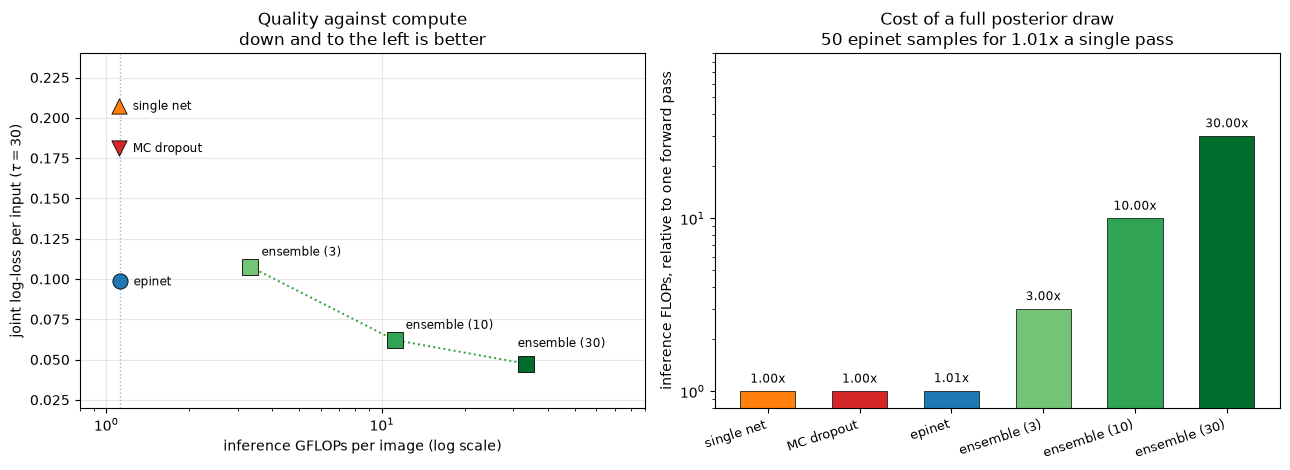

In [22]:
cost_order = [
    "single net",
    "MC dropout",
    "epinet",
    "ensemble (3 members)",
    "ensemble (10 members)",
    "ensemble (30 members)",
]
tau_show = 30
joint_at_tau = {n: curves[n][taus.index(tau_show)] for n in cost_order}
# (dx, dy) label offsets in points, tuned to keep annotations off the markers
offsets = {
    "single net": (10, -3),
    "MC dropout": (10, -3),
    "epinet": (10, -3),
    "ensemble (3 members)": (8, 8),
    "ensemble (10 members)": (8, 8),
    "ensemble (30 members)": (-6, 12),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ens = [n for n in cost_order if n.startswith("ensemble")]
ax.plot(
    [flop_counts[n] / 1e9 for n in ens],
    [joint_at_tau[n] for n in ens],
    color="C2",
    ls=":",
    lw=1.4,
    zorder=1,
)
ax.axvline(flop_counts["epinet"] / 1e9, color="C0", ls=":", lw=1, alpha=0.5, zorder=0)
for name in cost_order:
    color, marker, _ = style[name]
    ax.scatter(
        flop_counts[name] / 1e9,
        joint_at_tau[name],
        c=color,
        marker=marker,
        s=120,
        edgecolor="k",
        lw=0.6,
        zorder=3,
    )
    ax.annotate(
        name.replace(" members", ""),
        (flop_counts[name] / 1e9, joint_at_tau[name]),
        textcoords="offset points",
        xytext=offsets[name],
        fontsize=8.5,
    )
ax.set_xscale("log")
ax.set_xlabel("inference GFLOPs per image (log scale)")
ax.set_ylabel(f"joint log-loss per input ($\\tau={tau_show}$)")
ax.set_title("Quality against compute\ndown and to the left is better")
ax.grid(alpha=0.3)
ax.set_xlim(0.8, 90)
ax.set_ylim(0.02, 0.24)

ax = axes[1]
x = np.arange(len(cost_order))
ratios = [flop_counts[n] / BASE_FLOPS for n in cost_order]
colors = [style[n][0] for n in cost_order]
ax.bar(x, ratios, 0.6, color=colors, edgecolor="k", lw=0.5)
for xi, r in zip(x, ratios):
    ax.text(xi, r * 1.12, f"{r:.2f}x", ha="center", fontsize=8.5)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(
    [n.replace(" members", "") for n in cost_order], rotation=18, ha="right", fontsize=9
)
ax.set_ylabel("inference FLOPs, relative to one forward pass")
ax.set_ylim(0.8, 90)
ax.set_title("Cost of a full posterior draw\n50 epinet samples for 1.01x a single pass")
plt.tight_layout()
plt.show()

In the left panel, the epinet is close to the single network's compute level while the ensemble reaches lower loss at substantially higher cost. At $\tau = 30$, the epinet's loss of 0.099 is lower than the 3-member ensemble's 0.108, at 1.01× the cost of a single forward pass rather than 3×. It does not match the 10- or 30-member ensembles, which cost 10× and 30× as much.

For this CIFAR-10 evaluation:

- The 30-member ensemble has the lowest joint log-loss on CIFAR-10. The epinet does not dominate the ensemble curve on this benchmark.
- The epinet improves joint-prediction quality with 0.7% more inference cost and 0.33% more trainable parameters than the frozen base network.

The choice depends on the available training and inference budget. The epinet is useful when a single trained network is available and repeated full-network evaluations are impractical.